# ImageNet事前訓練拡散モデルを医療画像分類で用いる

はじめに医療データセットに対してResNet50で分類を行う。
なお事前に得ていた事前訓練済みの分類機を用いる。データセットはkaggleのデータセットを用いる。

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import os
from PIL import Image
import numpy as np
from tqdm.auto import tqdm  # これを追加

DATA_DIR = '/mnt/data1/gotou/projects/Medical/kaggledata'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train')
LABELS_CSV = os.path.join(DATA_DIR, 'train_labels.csv')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test')

# データ拡張（学習時のみ）
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PCamDataset(Dataset):
    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir = img_dir
        self.labels = labels_df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        img_id = self.labels.iloc[idx, 0]
        label = self.labels.iloc[idx, 1]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

labels_df = pd.read_csv(LABELS_CSV)
train_df, val_df = train_test_split(labels_df, test_size=0.1, random_state=42, stratify=labels_df['label'])

train_dataset = PCamDataset(TRAIN_IMG_DIR, train_df, train_transform)
val_dataset = PCamDataset(TRAIN_IMG_DIR, val_df, val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

resnet50.fc = nn.Linear(resnet50.fc.in_features, 1)
model = resnet50.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)


"""
# EarlyStopping & モデル保存
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, path='best_model_weights.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.delta = delta
        self.best_model = None
        self.path = path

    def __call__(self, val_acc, model):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        '''ベストモデルを保存'''
        torch.save(model.state_dict(), self.path)
        # deepcopy して参照を切る
        self.best_model = copy.deepcopy(model.state_dict())
        if self.verbose:
            print(f'Validation accuracy improved → saving model to {self.path}')

            """


"\n# EarlyStopping & モデル保存\nclass EarlyStopping:\n    def __init__(self, patience=5, verbose=False, delta=0, path='best_model_weights.pth'):\n        self.patience = patience\n        self.verbose = verbose\n        self.counter = 0\n        self.best_score = None\n        self.early_stop = False\n        self.delta = delta\n        self.best_model = None\n        self.path = path\n\n    def __call__(self, val_acc, model):\n        score = val_acc\n        if self.best_score is None:\n            self.best_score = score\n            self.save_checkpoint(model)\n        elif score < self.best_score + self.delta:\n            self.counter += 1\n            if self.verbose:\n                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')\n            if self.counter >= self.patience:\n                self.early_stop = True\n        else:\n            self.best_score = score\n            self.save_checkpoint(model)\n            self.counter = 0\n\n    def save_checkp

In [2]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# モデル定義（学習時と同じ）
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)  # 1ユニット出力
model = model.to(device)

# 重みロード
ckpt_path = "/mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model from {ckpt_path}")


/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded model from /mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth


In [3]:
import torch
import torch.nn as nn

# --- 攻撃関数 ---
import torch.nn.functional as F

import torch

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

# 前提: device, mean, std が外部で定義されている（投稿の定義をそのまま使えます）
# MEAN = np.array([...]); STD = np.array([...])
# mean = torch.tensor(MEAN).view(1,3,1,1).to(device)
# std  = torch.tensor(STD).view(1,3,1,1).to(device)

def denormalize(x, mean, std):
    # normalized -> pixel [0,1]
    return x * std + mean

def renormalize(x_pixel, mean, std):
    # pixel [0,1] -> normalized
    return (x_pixel - mean) / std

def fgsm_attack_improved(model, images, labels, epsilon_pixel, device,
                         mean_tensor=None, std_tensor=None, return_preds=True):
    """
    FGSM attack that respects per-channel normalization.
    Args:
      model: nn.Module, expects normalized inputs (same normalization used here)
      images: normalized tensor [B,C,H,W] (already normalized by mean/std)
      labels: tensor [B] (0/1) or shape [B,1]
      epsilon_pixel: float (e.g. 8/255) or tensor broadcastable to channels (pixel-scale)
      device: torch.device
      mean_tensor, std_tensor: tensors shaped [1,C,1,1] on device (if None, must be global)
      return_preds: if True, also return predicted labels on adversarial images
    Returns:
      adv_images: tensor [B,C,H,W] (normalized, detached)
      adv_preds (optional): LongTensor [B] predicted labels on adv_images (cpu)
    """
    # use provided mean/std or expect global variables `mean`/`std`
    if mean_tensor is None or std_tensor is None:
        # these should exist in your scope (as in your snippet)
        mean_tensor_local = mean
        std_tensor_local = std
    else:
        mean_tensor_local = mean_tensor
        std_tensor_local = std_tensor

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    images.requires_grad = True

    # model output: assume logits for binary classification -> shape [B] or [B,1]
    outputs = model(images)
    if outputs.ndim > 1 and outputs.shape[1] == 1:
        outputs = outputs.squeeze(1)  # [B]
    # binary cross entropy with logits
    loss = F.binary_cross_entropy_with_logits(outputs, labels.float())
    model.zero_grad()
    loss.backward()
    grad = images.grad.data  # gradient in normalized space

    # sign of gradient in normalized space
    grad_sign = grad.sign()

    # convert epsilon_pixel (pixel scale: 0..1) -> normalized-space epsilon per channel
    # support scalar epsilon_pixel or iterable per-channel
    if not torch.is_tensor(epsilon_pixel):
        eps_pixel_tensor = torch.tensor(epsilon_pixel, dtype=images.dtype, device=device)
    else:
        eps_pixel_tensor = epsilon_pixel.to(device).to(images.dtype)

    # make eps_norm shaped [1,C,1,1]
    if eps_pixel_tensor.ndim == 0:
        eps_norm = (eps_pixel_tensor / std_tensor_local).view(1, -1, 1, 1)
    elif eps_pixel_tensor.ndim == 1 and eps_pixel_tensor.numel() == std_tensor_local.shape[1]:
        eps_norm = (eps_pixel_tensor.view(1, -1, 1, 1) / std_tensor_local)
    else:
        # fallback: try to broadcast
        eps_norm = (eps_pixel_tensor / std_tensor_local)

    # create adversarial images in normalized space
    adv_images = images + eps_norm * grad_sign

    # clamp in pixel space
    adv_pixel = denormalize(adv_images, mean_tensor_local, std_tensor_local)
    adv_pixel = torch.clamp(adv_pixel, 0.0, 1.0)

    # back to normalized space
    adv_images = renormalize(adv_pixel, mean_tensor_local, std_tensor_local).detach()
    adv_images.requires_grad = False

    if return_preds:
        with torch.no_grad():
            adv_out = model(adv_images)
            if adv_out.ndim > 1 and adv_out.shape[1] == 1:
                adv_out = adv_out.squeeze(1)
            adv_probs = torch.sigmoid(adv_out)
            adv_preds = (adv_probs > 0.5).long().cpu()
        # cleanup
        del grad, grad_sign, adv_out, adv_pixel, eps_norm, eps_pixel_tensor, loss
        torch.cuda.empty_cache()
        return adv_images, adv_preds

    # cleanup
    del grad, grad_sign, adv_pixel, eps_norm, eps_pixel_tensor, loss
    torch.cuda.empty_cache()
    return adv_images





In [4]:
# evaluate_clean_and_fgsm(model, val_loader, device, epsilon_pixel=30/255, mean=mean, std=std)
# original_acc, adversarial_acc = evaluate_clean_and_fgsm(model, val_loader, device, epsilon_pixel=0.01, mean=mean, std=std)

In [5]:
"""import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch

# --- 設定 ---
num_display = 10  # 先頭何枚を可視化するか

# 表示用 unnormalize（正規化 -> pixel [0,1]）
def unnormalize_tensor(x):
    return x * std.to(x.device) + mean.to(x.device)

# データを少しだけ取得
it = iter(val_loader)
collected = 0
rows = []

while collected < num_display:
    try:
        batch = next(it)
    except StopIteration:
        break
    images, labels = batch
    B = images.shape[0]
    take = min(B, num_display - collected)
    imgs = images[:take].to(device)
    labs = labels[:take].to(device)

    # FGSM攻撃
    adv_images, adv_preds = fgsm_attack_improved(
        model, imgs, labs, epsilon_pixel=8/255, device=device,
        mean_tensor=mean, std_tensor=std, return_preds=True
    )

    rows.append({
        "clean": imgs.detach().cpu(),
        "adv": adv_images.detach().cpu()
    })

    collected += take

# --- 描画 ---
plt.figure(figsize=(6, 3 * num_display))
idx = 0
for r in rows:
    B = r["clean"].shape[0]
    for i in range(B):
        # 元画像
        plt.subplot(num_display, 2, idx * 2 + 1)
        img_clean = unnormalize_tensor(r["clean"][i].to(device)).cpu()
        if img_clean.ndim == 4:
            img_clean = img_clean.squeeze(0)
        plt.imshow(TF.to_pil_image(img_clean))
        plt.title("Clean")
        plt.axis("off")

        # 敵対画像
        plt.subplot(num_display, 2, idx * 2 + 2)
        img_adv = unnormalize_tensor(r["adv"][i].to(device)).cpu()
        if img_adv.ndim == 4:
            img_adv = img_adv.squeeze(0)
        plt.imshow(TF.to_pil_image(img_adv))
        plt.title("Adversarial")
        plt.axis("off")

        idx += 1

plt.tight_layout()
plt.show()"""


'import matplotlib.pyplot as plt\nimport torchvision.transforms.functional as TF\nimport torch\n\n# --- 設定 ---\nnum_display = 10  # 先頭何枚を可視化するか\n\n# 表示用 unnormalize（正規化 -> pixel [0,1]）\ndef unnormalize_tensor(x):\n    return x * std.to(x.device) + mean.to(x.device)\n\n# データを少しだけ取得\nit = iter(val_loader)\ncollected = 0\nrows = []\n\nwhile collected < num_display:\n    try:\n        batch = next(it)\n    except StopIteration:\n        break\n    images, labels = batch\n    B = images.shape[0]\n    take = min(B, num_display - collected)\n    imgs = images[:take].to(device)\n    labs = labels[:take].to(device)\n\n    # FGSM攻撃\n    adv_images, adv_preds = fgsm_attack_improved(\n        model, imgs, labs, epsilon_pixel=8/255, device=device,\n        mean_tensor=mean, std_tensor=std, return_preds=True\n    )\n\n    rows.append({\n        "clean": imgs.detach().cpu(),\n        "adv": adv_images.detach().cpu()\n    })\n\n    collected += take\n\n# --- 描画 ---\nplt.figure(figsize=(6, 3 * num_disp

/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded classifier and ddpm.


Eval loop: 100%|██████████| 688/688 [07:21<00:00,  1.56it/s]



==== Results ====
Total samples evaluated: 22003
Clean accuracy:     0.9811
Adv (FGSM) accuracy:0.5761
Purified accuracy:  0.5950
Saved example images to: purify_examples

Confusion Matrix Analysis


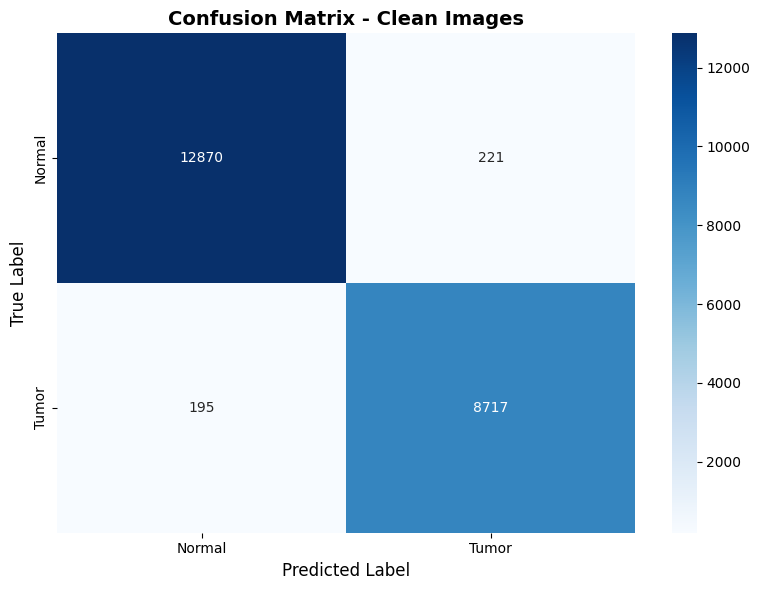


Confusion Matrix - Clean Images:
  True Negatives:  12870
  False Positives: 221
  False Negatives: 195
  True Positives:  8717
  Precision: 0.9753
  Recall:    0.9781
  F1-Score:  0.9767


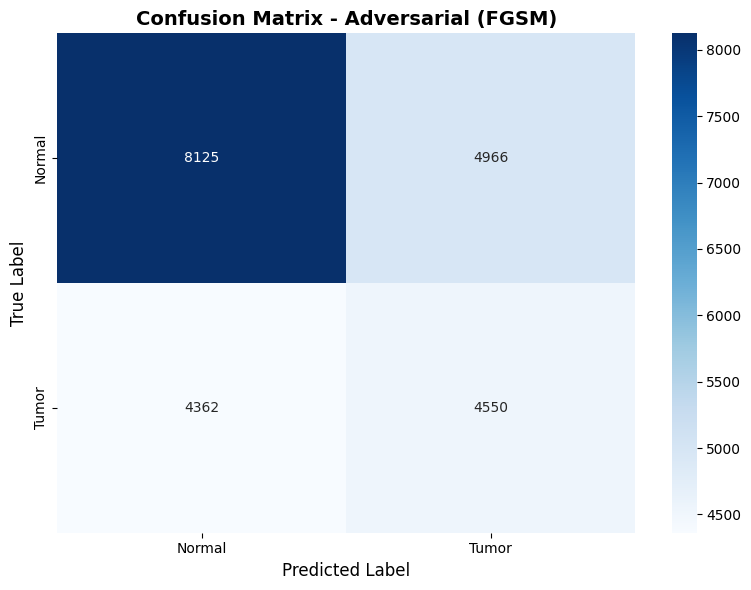


Confusion Matrix - Adversarial (FGSM):
  True Negatives:  8125
  False Positives: 4966
  False Negatives: 4362
  True Positives:  4550
  Precision: 0.4781
  Recall:    0.5105
  F1-Score:  0.4938


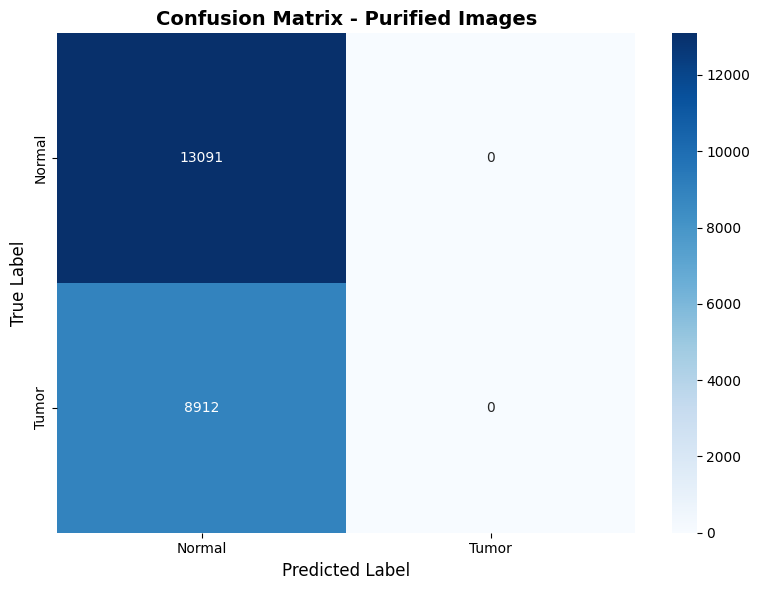


Confusion Matrix - Purified Images:
  True Negatives:  13091
  False Positives: 0
  False Negatives: 8912
  True Positives:  0
  Precision: nan
  Recall:    0.0000
  F1-Score:  0.0000


/tmp/ipykernel_1106059/4056343243.py:234: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Precision: {tp/(tp+fp):.4f}")


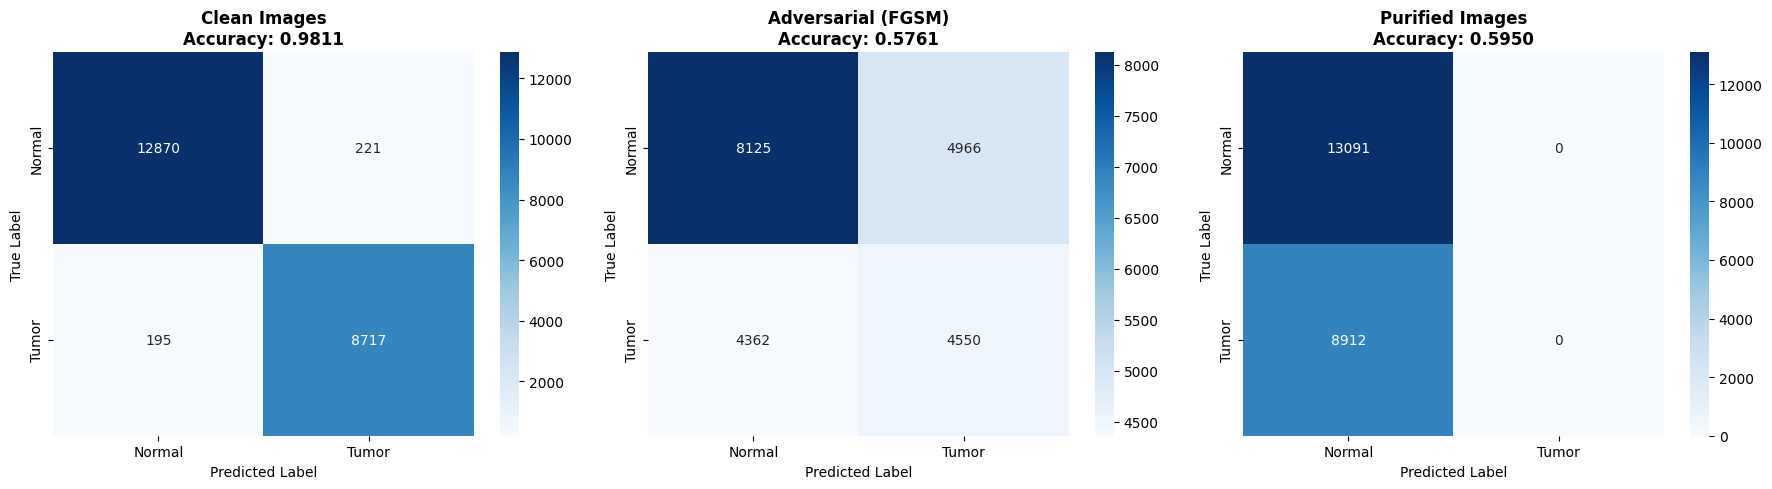


✅ All confusion matrices saved to: purify_examples


In [9]:
# ddpm_purify_eval_pipeline.py
import os
import torch
import torch.nn.functional as F
from torchvision.utils import make_grid, save_image
from tqdm import tqdm
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ---------- Basic device / paths ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ddpm_ckpt = "/mnt/data1/gotou/kaggle/denoising/ddpm_checkpoints/ddpm_pcam_epoch50.pth"
clf_ckpt  = "/mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth"

# --- SimpleUNet (学習時と一致) ---
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(base_channels, base_channels*2, 3, 2, 1),
            nn.ReLU(),
        )
        self.middle = nn.Sequential(
            nn.Conv2d(base_channels*2, base_channels*2, 3, 1, 1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(base_channels*2, base_channels, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(base_channels, out_channels, 3, 1, 1)
        )

    def forward(self, x, t_emb):
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        return x

# --- βスケジュール（学習時と同じ） ---
T_steps = 1000
betas = torch.linspace(1e-4, 0.02, T_steps).to(device)
alphas = (1 - betas).to(device)
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)

# --- load ddpm ---
ddpm = SimpleUNet().to(device)
ddpm.load_state_dict(torch.load(ddpm_ckpt, map_location=device))
ddpm.eval()

# --- diffusion_purify ---
@torch.no_grad()
def diffusion_purify(x_adv_minus1to1, model, start_t=500, T_purify=100):
    b = x_adv_minus1to1.size(0)
    t = torch.full((b,), start_t, device=device, dtype=torch.long)
    noise = torch.randn_like(x_adv_minus1to1)

    sqrt_alphas_cumprod = alphas_cumprod[t] ** 0.5
    sqrt_one_minus_alphas_cumprod = (1 - alphas_cumprod[t]) ** 0.5
    x_t = sqrt_alphas_cumprod[:, None, None, None] * x_adv_minus1to1 + \
          sqrt_one_minus_alphas_cumprod[:, None, None, None] * noise

    step_range = range(start_t, max(start_t - T_purify, 0), -1)
    for t_ in step_range:
        t_batch = torch.full((b,), t_, device=device, dtype=torch.long)
        eps_pred = model(x_t, t_batch)
        beta_t = betas[t_]
        alpha_t = alphas[t_]
        alpha_bar_t = alphas_cumprod[t_]
        if t_ > 0:
            z = torch.randn_like(x_t)
        else:
            z = 0
        x_t = (1 / alpha_t**0.5) * (
            x_t - (1 - alpha_t) / (1 - alpha_bar_t)**0.5 * eps_pred
        ) + beta_t**0.5 * z

    return x_t

# ---------- normalization utilities ----------
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)

def unnormalize(x_norm):
    return x_norm * imagenet_std + imagenet_mean

def renormalize(x, mean, std):
    return (x - mean) / std

def prepare_for_diffusion_from_norm(x_norm, target_size=64):
    x_pixel = unnormalize(x_norm)
    x_resized = F.interpolate(x_pixel, size=(target_size, target_size), mode="bilinear", align_corners=False)
    x_minus1to1 = (x_resized - 0.5) * 2.0
    return x_minus1to1

def recover_from_diffusion_to_norm(x_minus1to1, out_size=224):
    x_pixel = (x_minus1to1 + 1) / 2.0
    x_pixel = torch.clamp(x_pixel, 0.0, 1.0)
    x_resized = F.interpolate(x_pixel, size=(out_size, out_size), mode="bilinear", align_corners=False)
    x_norm = renormalize(x_resized, imagenet_mean, imagenet_std)
    return x_norm

# ---------- load classifier ----------
clf = models.resnet50(pretrained=False)
clf.fc = nn.Linear(clf.fc.in_features, 1)
clf.load_state_dict(torch.load(clf_ckpt, map_location=device))
clf = clf.to(device)
clf.eval()
print("Loaded classifier and ddpm.")

# ---------- evaluation loop ----------
epsilon_pixel = 8/255.0
start_t = 500
T_purify = 100
save_examples_dir = "purify_examples"
os.makedirs(save_examples_dir, exist_ok=True)

total = 0
correct_clean = 0
correct_adv = 0
correct_purified = 0

# 混同行列用のリスト
all_labels = []
all_preds_clean = []
all_preds_adv = []
all_preds_purified = []

# loop
for batch_idx, (images_norm, labels) in enumerate(tqdm(val_loader, desc="Eval loop")):
    images_norm = images_norm.to(device)
    labels = labels.to(device).long().view(-1)
    b = images_norm.size(0)
    total += b

    # ラベル保存
    all_labels.extend(labels.cpu().numpy())

    # ---------- 1) clean prediction ----------
    with torch.no_grad():
        logits_clean = clf(images_norm)
        if logits_clean.ndim > 1 and logits_clean.shape[1] == 1:
            logits_clean = logits_clean.squeeze(1)
        probs_clean = torch.sigmoid(logits_clean)
        preds_clean = (probs_clean > 0.5).long()
        correct_clean += (preds_clean.cpu() == labels.cpu()).sum().item()
        all_preds_clean.extend(preds_clean.cpu().numpy())

    # ---------- 2) adversarial example (FGSM) ----------
    adv_images_norm, adv_preds_from_attack = fgsm_attack_improved(
        model=clf,
        images=images_norm,
        labels=labels,
        epsilon_pixel=epsilon_pixel,
        device=device,
        mean_tensor=imagenet_mean,
        std_tensor=imagenet_std,
        return_preds=True
    )
    adv_images_norm = adv_images_norm.to(device)
    adv_preds_from_attack = adv_preds_from_attack.to(device)
    correct_adv += (adv_preds_from_attack.cpu() == labels.cpu()).sum().item()
    all_preds_adv.extend(adv_preds_from_attack.cpu().numpy())

    # ---------- 3) prepare for diffusion & purify ----------
    x_adv_for_diff = prepare_for_diffusion_from_norm(adv_images_norm, target_size=64)
    purified_minus1to1 = diffusion_purify(x_adv_for_diff, ddpm, start_t=start_t, T_purify=T_purify)

    # ---------- 4) recover to classifier-normalized inputs and classify ----------
    purified_norm = recover_from_diffusion_to_norm(purified_minus1to1, out_size=224)
    with torch.no_grad():
        logits_pur = clf(purified_norm)
        if logits_pur.ndim > 1 and logits_pur.shape[1] == 1:
            logits_pur = logits_pur.squeeze(1)
        probs_pur = torch.sigmoid(logits_pur)
        preds_pur = (probs_pur > 0.5).long()
        correct_purified += (preds_pur.cpu() == labels.cpu()).sum().item()
        all_preds_purified.extend(preds_pur.cpu().numpy())

    # ---------- save example triplets ----------
    if batch_idx < 5:
        n_save = min(8, b)
        clean_pixel = unnormalize(images_norm[:n_save].detach()).clamp(0,1)
        adv_pixel   = unnormalize(adv_images_norm[:n_save].detach()).clamp(0,1)
        pur_pixel   = (purified_minus1to1[:n_save].detach() + 1.0) / 2.0
        pur_pixel = F.interpolate(pur_pixel, size=(224,224), mode="bilinear", align_corners=False)
        clean_resized = F.interpolate(clean_pixel, size=(224,224), mode="bilinear", align_corners=False)

        rows = []
        for i in range(n_save):
            row = torch.cat([clean_resized[i], adv_pixel[i], pur_pixel[i]], dim=2)
            rows.append(row)
        grid = make_grid(torch.stack(rows), nrow=1)
        save_image(grid, os.path.join(save_examples_dir, f"triplets_batch{batch_idx}.png"))

# ---------- final results ----------
clean_acc = correct_clean / total
adv_acc = correct_adv / total
pur_acc = correct_purified / total

print("\n==== Results ====")
print(f"Total samples evaluated: {total}")
print(f"Clean accuracy:     {clean_acc:.4f}")
print(f"Adv (FGSM) accuracy:{adv_acc:.4f}")
print(f"Purified accuracy:  {pur_acc:.4f}")
print(f"Saved example images to: {save_examples_dir}")

# ---------- 混同行列の計算と可視化 ----------
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Tumor'],
                yticklabels=['Normal', 'Tumor'])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    # 詳細統計を表示
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")
    print(f"  Precision: {tp/(tp+fp):.4f}")
    print(f"  Recall:    {tp/(tp+fn):.4f}")
    print(f"  F1-Score:  {2*tp/(2*tp+fp+fn):.4f}")

# 3つの混同行列を生成
print("\n" + "="*50)
print("Confusion Matrix Analysis")
print("="*50)

plot_confusion_matrix(
    all_labels, all_preds_clean,
    "Confusion Matrix - Clean Images",
    os.path.join(save_examples_dir, "confusion_matrix_clean.png")
)

plot_confusion_matrix(
    all_labels, all_preds_adv,
    "Confusion Matrix - Adversarial (FGSM)",
    os.path.join(save_examples_dir, "confusion_matrix_adversarial.png")
)

plot_confusion_matrix(
    all_labels, all_preds_purified,
    "Confusion Matrix - Purified Images",
    os.path.join(save_examples_dir, "confusion_matrix_purified.png")
)

# ---------- 3つの混同行列を並べて表示 ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_clean = confusion_matrix(all_labels, all_preds_clean)
cm_adv = confusion_matrix(all_labels, all_preds_adv)
cm_pur = confusion_matrix(all_labels, all_preds_purified)

titles = ['Clean Images', 'Adversarial (FGSM)', 'Purified Images']
cms = [cm_clean, cm_adv, cm_pur]
accs = [clean_acc, adv_acc, pur_acc]

for ax, cm, title, acc in zip(axes, cms, titles, accs):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Tumor'],
                yticklabels=['Normal', 'Tumor'])
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(save_examples_dir, 'confusion_matrix_comparison.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ All confusion matrices saved to: {save_examples_dir}")